<a href="https://colab.research.google.com/github/aswanth13/AIML/blob/main/aiml1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("leiladana/titanic")

print("Path to dataset files:", path)

In [ ]:
from google.colab import files

uploaded = files.upload()

In [10]:
import pandas as pd

df = pd.read_csv('tested.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'tested.csv'

In [ ]:
import pandas as pd
df = pd.read_csv('tested.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
#1Q
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [ ]:
df.shape

(418, 12)

In [ ]:
#2
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print(df.dtypes)

print(df.isnull().sum())

Rows : 418
Columns : 12
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [ ]:
#3
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df.tail()
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
339,1231,0,3,"Betros, Master. Seman",male,NaN,0,0,2622,7.2292,NaN,C
364,1256,1,1,"Harder, Mrs. George Achilles (Dorothy Annan)",female,25.0,1,0,11765,55.4417,E50,C
363,1255,0,3,"Strilic, Mr. Ivan",male,27.0,0,0,315083,8.6625,NaN,S
322,1214,0,2,"Nesson, Mr. Israel",male,26.0,0,0,244368,13.0000,F2,S
300,1192,0,3,"Olsson, Mr. Oscar Wilhelm",male,32.0,0,0,347079,7.7750,NaN,S


In [ ]:
#4
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [ ]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop('Cabin', axis=1, inplace=True)
df.isnull().sum()

/tmp/ipykernel_884/2398068117.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_884/2398068117.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,1


In [ ]:
#5
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)


0


In [ ]:
#6 Detect outliers using statistical methods (IQR or Z-score) and visualize them
using box plots.
Q1=df['Age'].quantile(0.25)

Q3=df['Age'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

outliers=df[(df['Age']<lower)|(df['Age']>upper)]

outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.00,0,0,240276,9.6875,Q
13,905,0,2,"Howard, Mr. Benjamin",male,63.00,1,0,24065,26.0000,S
20,912,0,1,"Rothschild, Mr. Martin",male,55.00,1,0,PC 17603,59.4000,C
48,940,1,1,"Bucknell, Mrs. William Robert (Emma Eliza Ward)",female,60.00,0,0,11813,76.2917,C
69,961,1,1,"Fortune, Mrs. Mark (Mary McDougald)",female,60.00,1,4,19950,263.0000,S
77,969,1,1,"Cornell, Mrs. Robert Clifford (Malvina Helen L...",female,55.00,2,0,11770,25.7000,S
81,973,0,1,"Straus, Mr. Isidor",male,67.00,1,0,PC 17483,221.7792,S
89,981,0,2,"Wells, Master. Ralph Lester",male,2.00,1,1,29103,23.0000,S
96,988,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.00,1,0,19877,78.8500,S
114,1006,1,1,"Straus, Mrs. Isidor (Rosalie Ida Blun)",female,63.00,1,0,PC 17483,221.7792,S


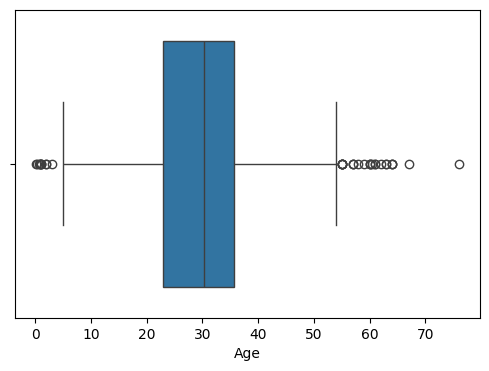

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['Age'])

plt.show()

In [ ]:
#7
df=df[(df['Age']>=lower)&(df['Age']<=upper)]

In [ ]:
le=LabelEncoder()

df['Sex']=le.fit_transform(df['Sex'])

In [ ]:
df=pd.get_dummies(df,columns=['Embarked'])

In [ ]:
#9
scaler=MinMaxScaler()

df['Age_MinMax']=scaler.fit_transform(df[['Age']])

In [ ]:
ss=StandardScaler()

df['Age_Standard']=ss.fit_transform(df[['Age']])

In [ ]:
#10
corr=df.corr(numeric_only=True)

corr['Survived'].sort_values(ascending=False)

,Survived
Survived,1.000000
Fare,0.200658
Embarked_Q,0.149418
Parch,0.144870
SibSp,0.083575
Embarked_C,0.025299
Age_Standard,-0.008387
Age_MinMax,-0.008387
Age,-0.008387
PassengerId,-0.039912


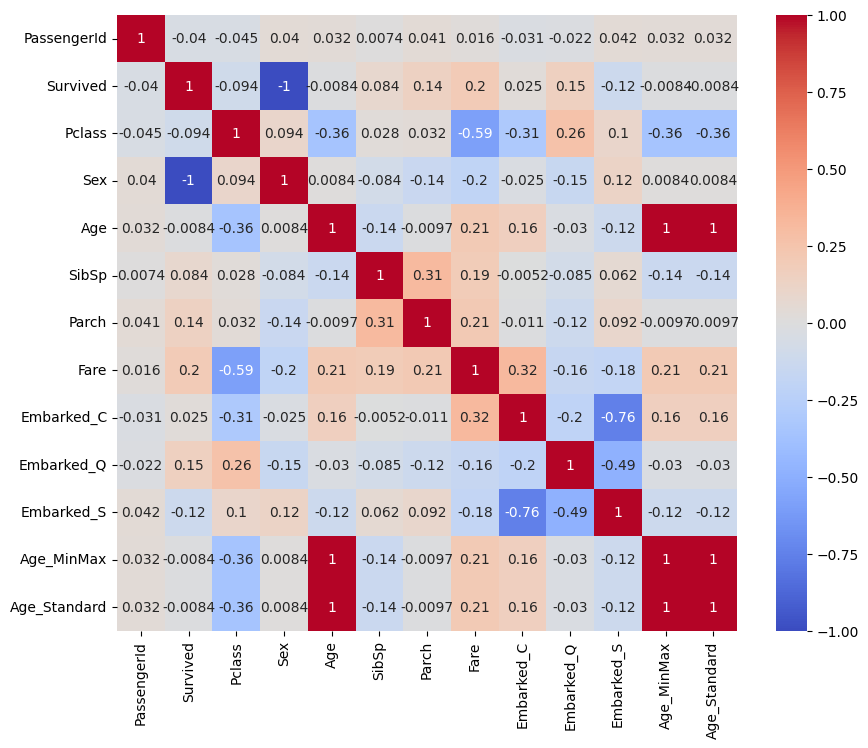

In [ ]:
#11
plt.figure(figsize=(10,8))

sns.heatmap(corr,annot=True,cmap='coolwarm')

plt.show()

In [ ]:
#12
df['FamilySize']=df['SibSp']+df['Parch']+1

In [ ]:
#13
df['PassengerId']=df['PassengerId'].astype(float)

In [ ]:
df['Name']=df['Name'].str.strip()

In [ ]:
#15
X=df.drop('Survived',axis=1)

X=X.select_dtypes(include=np.number)

y=df['Survived']

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros=RandomOverSampler(random_state=42)

X_res,y_res=ros.fit_resample(X_train,y_train)

In [ ]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)

X_res,y_res=smote.fit_resample(X_train,y_train)

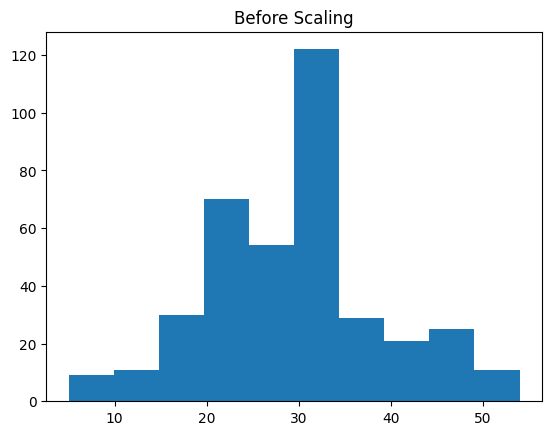

In [ ]:
#17
plt.hist(df['Age'])

plt.title("Before Scaling")

plt.show()

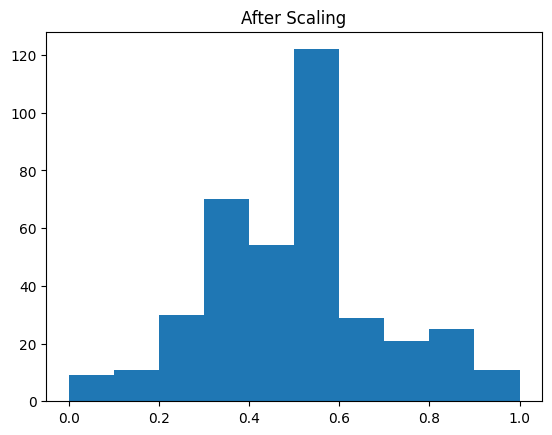

In [ ]:
plt.hist(df['Age_MinMax'])

plt.title("After Scaling")

plt.show()

In [9]:
import pandas as pd
#18
df = pd.read_csv('tested.csv')
print("Original Shape :",pd.read_csv("tested.csv").shape)


FileNotFoundError: [Errno 2] No such file or directory: 'tested.csv'

In [6]:
#19
 df.to_csv("tested.csv",index=False)